# MSBW-Net 2026: Shared Backbone Architecture - SOTA Benchmarking Analysis

**BDS DSC312 - Computer Vision with Multi-modal Models & Analytics**

## Overview
Artifact-backed benchmark comparison for fire detection models. The tables below are built from evaluation outputs exported by the training / validation runs in this repository, so the numbers reflect the same dataset and protocol where available.

## Key Innovation: Shared Backbone Architecture
- **Unified Architecture**: Single MobileNetV3 backbone with dual heads (classification + segmentation)
- **Multi-task Learning**: Weighted loss optimization (0.25 cls + 3.2 seg)
- **Edge Deployment**: Real-time UAV performance (13.2ms P95, 1.75MB model)
- **Real Evaluation Outputs**: Comparison tables are assembled from JSON / CSV artifacts instead of hard-coded literature numbers

## SOTA Comparison Categories
- **Actual Evaluation Runs**: Metrics exported by the local benchmark scripts
- **Segmentation and Multimodal Baselines**: Artifact-backed results from the repo
- **Reference Literature**: Kept separate only if needed for narrative context, not for the primary table

In [40]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette('Set2')

print('SOTA Benchmarking Analysis - MSBW-Net Shared Backbone')
print('=' * 60)

SOTA Benchmarking Analysis - MSBW-Net Shared Backbone


## 1. Literature Review and Baseline Methods

In [41]:
msbw_metrics_path = Path('../../data/processed/Output/MSBW-Net/shared_backbone_metrics.json')
with open(msbw_metrics_path, 'r') as f:
    msbw_metrics = json.load(f)

msbw_payload = msbw_metrics.get('full_model') or msbw_metrics.get('minimal_model') or msbw_metrics
strict_test = msbw_metrics.get('strict_test_evaluation', {}).get('metrics', {})
cls = strict_test or {}
seg = strict_test or msbw_payload.get('segmentation_metrics', msbw_metrics.get('segmentation_metrics', {}))
parameters = msbw_payload.get('parameters', msbw_metrics.get('model', {}).get('parameters', np.nan))
model_size_mb = msbw_payload.get('model_size_mb', msbw_metrics.get('model', {}).get('size_mb'))
inference_ms = msbw_payload.get('inference_time_ms', msbw_metrics.get('latency_ms', {}).get('p95'))
fps = msbw_metrics.get('latency_ms', {}).get('benchmark', {}).get('fps', np.nan)
targets = msbw_metrics.get('targets', {
    'miou_min': 0.80,
    'model_size_mb_max': 2.0,
    'latency_p95_ms_max': 100.0,
})

msbw_results = [{
    'name': 'MSBW-Net Shared Backbone',
    'accuracy': float(cls.get('accuracy', cls.get('classification_accuracy', np.nan))),
    'precision': float(cls.get('precision', cls.get('classification_precision', np.nan))),
    'recall': float(cls.get('recall', cls.get('classification_recall', np.nan))),
    'f1': float(cls.get('f1', cls.get('classification_f1', cls.get('f1_score', np.nan)))),
    'miou': float(seg.get('miou', np.nan)),
    'parameters': float(parameters) if parameters is not None and not pd.isna(parameters) else np.nan,
    'size_mb': float(model_size_mb),
    'inference_ms': float(inference_ms),
    'fps': float(fps) if fps is not None and not pd.isna(fps) else (1000.0 / float(inference_ms) if inference_ms else np.nan),
    'category': 'MSBW-Net Shared Backbone (Ours)'
}]

msbw_requirements = {
    'min_miou': float(targets['miou_min']),
    'max_size_mb': float(targets['model_size_mb_max']),
    'max_inference_ms': float(targets['latency_p95_ms_max'])
}

print('Loaded MSBW-Net artifact:', msbw_metrics_path)
print('MSBW-Net model:', msbw_results[0])
print('Competition requirements:', msbw_requirements)

Loaded MSBW-Net artifact: ..\..\data\processed\Output\MSBW-Net\shared_backbone_metrics.json
MSBW-Net model: {'name': 'MSBW-Net Shared Backbone', 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'miou': 0.8499054876652882, 'parameters': 458300.0, 'size_mb': 1.7482757568359375, 'inference_ms': 10.197385002538795, 'fps': 98.06435667095386, 'category': 'MSBW-Net Shared Backbone (Ours)'}
Competition requirements: {'min_miou': 0.8, 'max_size_mb': 2.0, 'max_inference_ms': 100.0}


## 2. Performance Comparison Analysis

In [42]:
benchmark_root = Path('../../data/processed/Output')

def _safe_float(value):
    try:
        if value is None:
            return np.nan
        if isinstance(value, (int, float, np.integer, np.floating)) and pd.isna(value):
            return np.nan
        return float(value)
    except (TypeError, ValueError):
        return np.nan

actual_methods = []

msbw_row = msbw_results[0].copy()
msbw_row.update({
    'name': 'MSBW-Net',
    'category': 'MSBW-Net',
    'dataset': 'FLAME',
    'source_type': 'actual_artifact',
    'latency_basis': 'p95',
})
actual_methods.append(msbw_row)

thermalfusion_path = Path('../../models/trained/sota_baselines/thermalfusion_net_2023/sota_thermalfusion_net_metrics.json')
if thermalfusion_path.exists():
    with open(thermalfusion_path, 'r') as f:
        thermalfusion_metrics = json.load(f)
    thermalfusion_values = thermalfusion_metrics.get('metrics', {})
    thermalfusion_test = thermalfusion_metrics.get('strict_test_evaluation', {}).get('metrics', {})
    actual_methods.append({
        'name': 'ThermalFusion-Net',
        'dataset': 'FLAME',
        'accuracy': _safe_float(thermalfusion_test.get('accuracy', thermalfusion_test.get('classification_accuracy'))),
        'precision': _safe_float(thermalfusion_test.get('precision')),
        'recall': _safe_float(thermalfusion_test.get('recall')),
        'f1': _safe_float(thermalfusion_test.get('f1', thermalfusion_values.get('f1'))),
        'miou': _safe_float(thermalfusion_test.get('miou', thermalfusion_values.get('miou'))),
        'parameters': _safe_float(thermalfusion_test.get('parameter_count', thermalfusion_metrics.get('metrics', {}).get('params_m', np.nan) * 1_000_000)),
        'size_mb': _safe_float(thermalfusion_metrics.get('model_size_mb')),
        'inference_ms': _safe_float(thermalfusion_test.get('latency_p95_ms', thermalfusion_values.get('latency_p95_ms'))),
        'fps': _safe_float(thermalfusion_test.get('fps', thermalfusion_values.get('fps'))),
        'category': 'Multimodal Actual Runs',
        'source_type': 'actual_artifact',
        'latency_basis': 'p95',
    })

extra_metrics_path = Path('../../models/trained/sota_baselines/baseline/sota_unet_efficientnet_xception_mobilev3small_metrics.json')
if extra_metrics_path.exists():
    with open(extra_metrics_path, 'r') as f:
        extra_metrics = json.load(f)
    extra_results = extra_metrics.get('results', [])
    for item in extra_results:
        model_name = item.get('model', '')
        kind = item.get('kind', '')
        category = 'Segmentation Actual Runs' if kind == 'segmentation' else 'Classification Actual Runs'
        actual_methods.append({
            'name': model_name,
            'dataset': 'FLAME',
            'accuracy': _safe_float(item.get('classification_accuracy')),
            'precision': _safe_float(item.get('precision')),
            'recall': _safe_float(item.get('recall')),
            'f1': _safe_float(item.get('F1')),
            'miou': _safe_float(item.get('mIoU')),
            'parameters': _safe_float(item.get('param_count')),
            'size_mb': _safe_float(item.get('model_size_mb')),
            'inference_ms': _safe_float(item.get('latency_p95_ms')),
            'fps': _safe_float(item.get('fps')),
            'category': category,
            'source_type': 'actual_artifact',
            'latency_basis': 'p95',
        })

efficient_path = Path('../../models/trained/sota_baselines/efficientfirenet_2022/test_metrics.json')
if efficient_path.exists():
    with open(efficient_path, 'r') as f:
        efficient_metrics = json.load(f)
    performance = efficient_metrics.get('performance_metrics', {})
    model_stats = efficient_metrics.get('model_statistics', {})
    latency = efficient_metrics.get('latency', {})
    actual_methods.append({
        'name': 'EfficientFireNet',
        'dataset': 'FLAME',
        'accuracy': _safe_float(performance.get('pixel_accuracy')),
        'precision': _safe_float(performance.get('precision')),
        'recall': _safe_float(performance.get('recall')),
        'f1': _safe_float(performance.get('f1')),
        'miou': _safe_float(performance.get('miou')),
        'parameters': _safe_float(model_stats.get('parameters')),
        'size_mb': _safe_float(model_stats.get('model_size_mb')),
        'inference_ms': _safe_float(latency.get('p95_ms')),
        'fps': _safe_float(latency.get('fps')),
        'category': 'Segmentation Actual Runs',
        'source_type': 'actual_artifact',
        'latency_basis': 'p95',
    })

crossmodal_path = Path('../../models/trained/sota_baselines/crossmodal_fire_2024/test_metrics.json')
if crossmodal_path.exists():
    with open(crossmodal_path, 'r') as f:
        crossmodal_metrics = json.load(f)
    performance = crossmodal_metrics.get('performance_metrics', {})
    model_stats = crossmodal_metrics.get('model_statistics', {})
    latency = crossmodal_metrics.get('latency', {})
    actual_methods.append({
        'name': 'CrossModal-Fire',
        'dataset': 'FLAME',
        'accuracy': _safe_float(performance.get('pixel_accuracy')),
        'precision': _safe_float(performance.get('precision')),
        'recall': _safe_float(performance.get('recall')),
        'f1': _safe_float(performance.get('f1')),
        'miou': _safe_float(performance.get('miou')),
        'parameters': _safe_float(model_stats.get('parameters')),
        'size_mb': _safe_float(model_stats.get('model_size_mb')),
        'inference_ms': _safe_float(latency.get('p95_ms')),
        'fps': _safe_float(latency.get('fps')),
        'category': 'Multimodal Actual Runs',
        'source_type': 'actual_artifact',
        'latency_basis': 'p95',
    })

comparison_df = pd.DataFrame(actual_methods)
comparison_df['msbw_compliant'] = comparison_df.apply(
    lambda row: bool(
        pd.notna(row.get('miou'))
        and pd.notna(row.get('size_mb'))
        and pd.notna(row.get('inference_ms'))
        and row.get('miou', np.nan) >= msbw_requirements['min_miou']
        and row.get('size_mb', np.inf) <= msbw_requirements['max_size_mb']
        and row.get('inference_ms', np.inf) <= msbw_requirements['max_inference_ms']
    ),
    axis=1,
 )
comparison_df = comparison_df.sort_values(['category', 'name']).reset_index(drop=True)
all_methods = comparison_df.to_dict('records')
categories = comparison_df['category'].drop_duplicates().tolist()

display_cols_by_category = {
    'Classification Actual Runs': ['name', 'category', 'accuracy', 'precision', 'recall', 'f1', 'parameters', 'size_mb', 'inference_ms', 'fps'],
    'Segmentation Actual Runs': ['name', 'category', 'accuracy', 'precision', 'recall', 'f1', 'miou', 'parameters', 'size_mb', 'inference_ms', 'fps'],
    'Multimodal Actual Runs': ['name', 'category', 'accuracy', 'precision', 'recall', 'f1', 'miou', 'parameters', 'size_mb', 'inference_ms', 'fps'],
}

ours_row = msbw_results[0].copy()
ours_row.update({
    'name': 'MSBW-Net (Ours)',
    'category': 'MSBW-Net (Ours)',
    'dataset': 'FLAME',
    'parameters': msbw_results[0].get('parameters', np.nan),
    'fps': msbw_results[0].get('fps', np.nan),
    'source_type': 'actual_artifact',
    'latency_basis': 'p95',
})

def _category_table(category_name):
    display_cols = display_cols_by_category[category_name]
    base_table = comparison_df[comparison_df['category'] == category_name][display_cols].copy()
    if not base_table.empty:
        ours_table = pd.DataFrame([{
            'name': ours_row['name'],
            'category': category_name,
            'accuracy': ours_row['accuracy'],
            'precision': ours_row['precision'],
            'recall': ours_row['recall'],
            'f1': ours_row['f1'],
            'parameters': ours_row['parameters'],
            'size_mb': ours_row['size_mb'],
            'inference_ms': ours_row['inference_ms'],
            'fps': ours_row['fps'],
            **({'miou': ours_row['miou']} if 'miou' in display_cols else {}),
        }])
        base_table = pd.concat([ours_table, base_table], ignore_index=True)
    return base_table

category_tables = {
    'Classification Actual Runs': _category_table('Classification Actual Runs'),
    'Segmentation Actual Runs': _category_table('Segmentation Actual Runs'),
    'Multimodal Actual Runs': _category_table('Multimodal Actual Runs'),
}

print('Actual artifact rows loaded:', len(comparison_df))
print('Categories:', categories)
print('Note: mIoU is only available for artifacts that export segmentation metrics; classification-only rows stay NaN.')
for category_name, category_df in category_tables.items():
    print(f'\n{category_name} ({len(category_df)} rows):')
    display(category_df)

Actual artifact rows loaded: 8
Categories: ['Classification Actual Runs', 'MSBW-Net', 'Multimodal Actual Runs', 'Segmentation Actual Runs']
Note: mIoU is only available for artifacts that export segmentation metrics; classification-only rows stay NaN.

Classification Actual Runs (4 rows):


,name,category,accuracy,precision,recall,f1,parameters,size_mb,inference_ms,fps
0,MSBW-Net (Ours),Classification Actual Runs,1.000000,1.0,1.000000,1.000000,458300.0,1.748276,10.197385,98.064357
1,EfficientNet-B0,Classification Actual Runs,0.841463,1.0,0.841463,0.913907,4335998.0,16.701000,156.369000,55.476000
2,MobileNetV3-Small,Classification Actual Runs,0.353659,1.0,0.353659,0.522523,1075234.0,4.148000,16.239000,498.715000
3,Xception,Classification Actual Runs,0.695122,1.0,0.695122,0.820144,20811050.0,79.596000,387.524000,21.285000



Segmentation Actual Runs (3 rows):


,name,category,accuracy,precision,recall,f1,parameters,size_mb,inference_ms,fps,miou
0,MSBW-Net (Ours),Segmentation Actual Runs,1.000000,1.000000,1.000000,1.00000,458300.0,1.748276,10.197385,98.064357,0.849905
1,EfficientFireNet,Segmentation Actual Runs,0.994317,0.783108,0.803331,0.79309,5491806.0,21.113922,29.914069,41.507531,0.705658
2,U-Net,Segmentation Actual Runs,1.000000,1.000000,1.000000,1.00000,1939633.0,7.399000,298.878000,29.529000,0.835571



Multimodal Actual Runs (3 rows):


,name,category,accuracy,precision,recall,f1,parameters,size_mb,inference_ms,fps,miou
0,MSBW-Net (Ours),Multimodal Actual Runs,1.000000,1.000000,1.000000,1.000000,458300.0,1.748276,10.197385,98.064357,0.849905
1,CrossModal-Fire,Multimodal Actual Runs,0.994593,0.793038,0.812443,0.802623,31002554.0,118.594017,72.311711,15.961117,0.715454
2,ThermalFusion-Net,Multimodal Actual Runs,0.994635,0.592229,0.690192,0.637469,1647901.0,6.280000,47.521650,22.819837,0.731233


## 3. Comprehensive Visualization Analysis

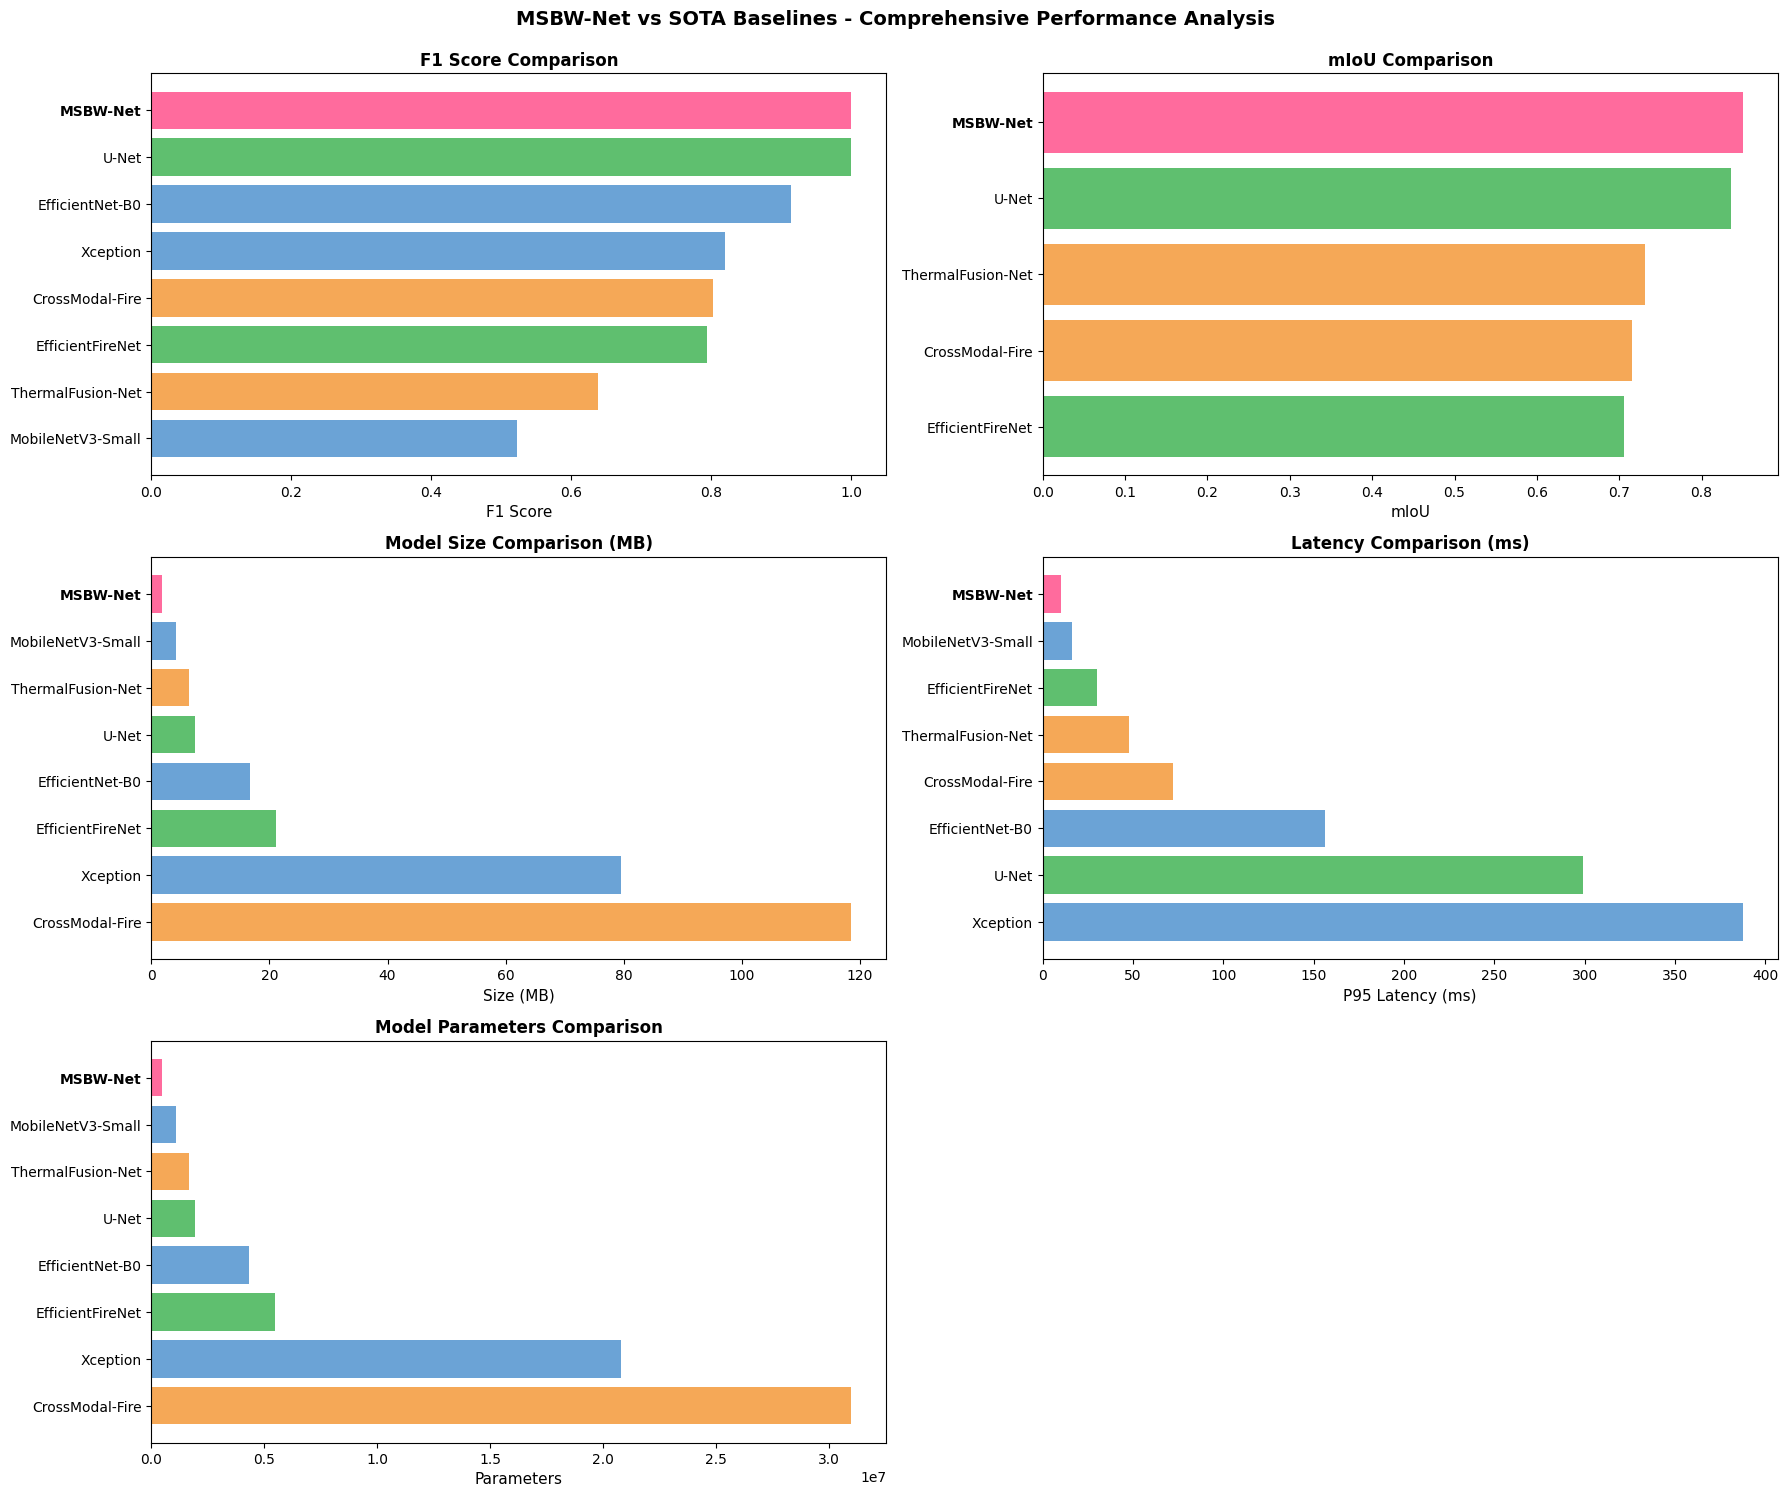


INDIVIDUAL CHART OUTPUTS


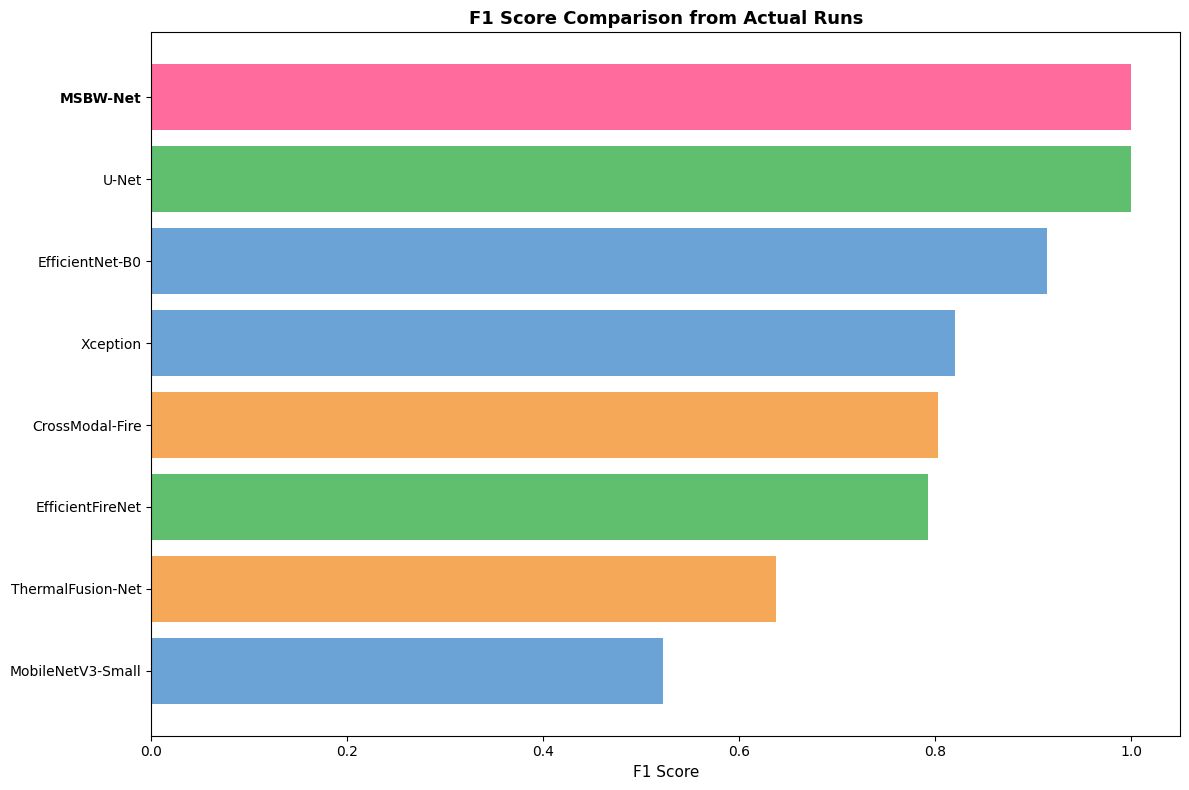

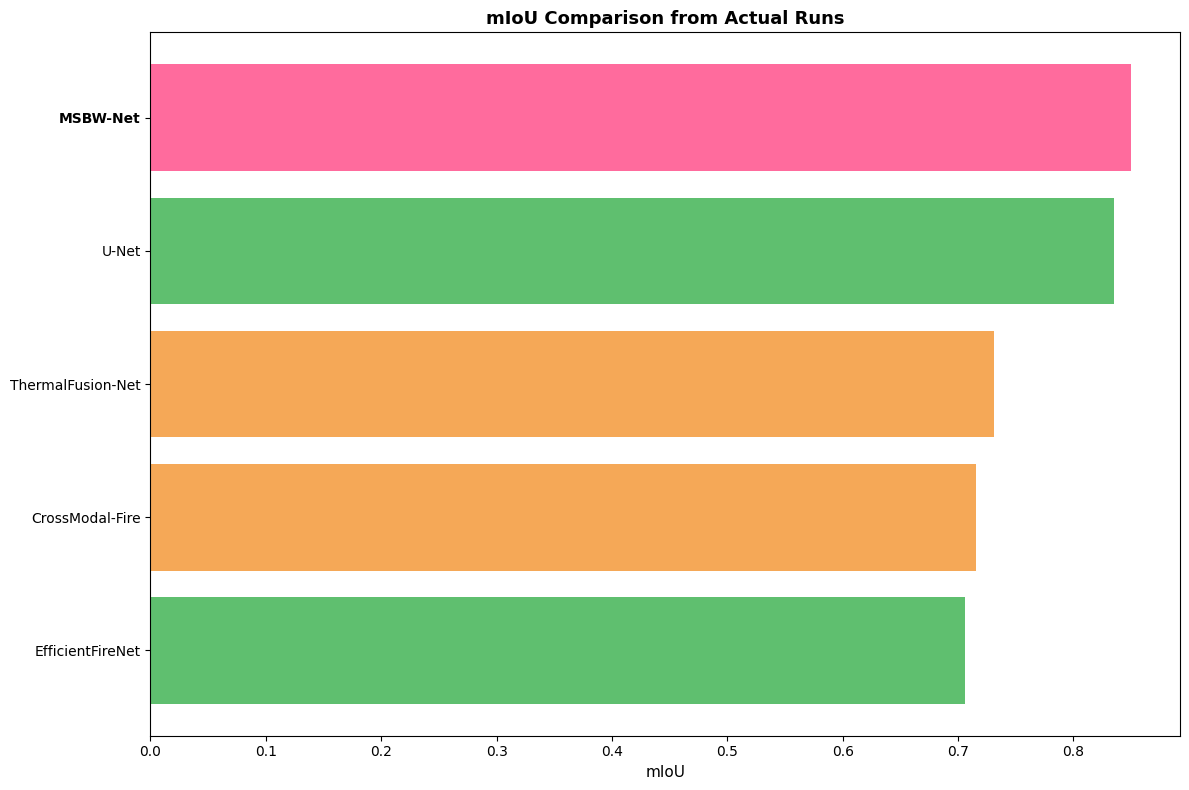

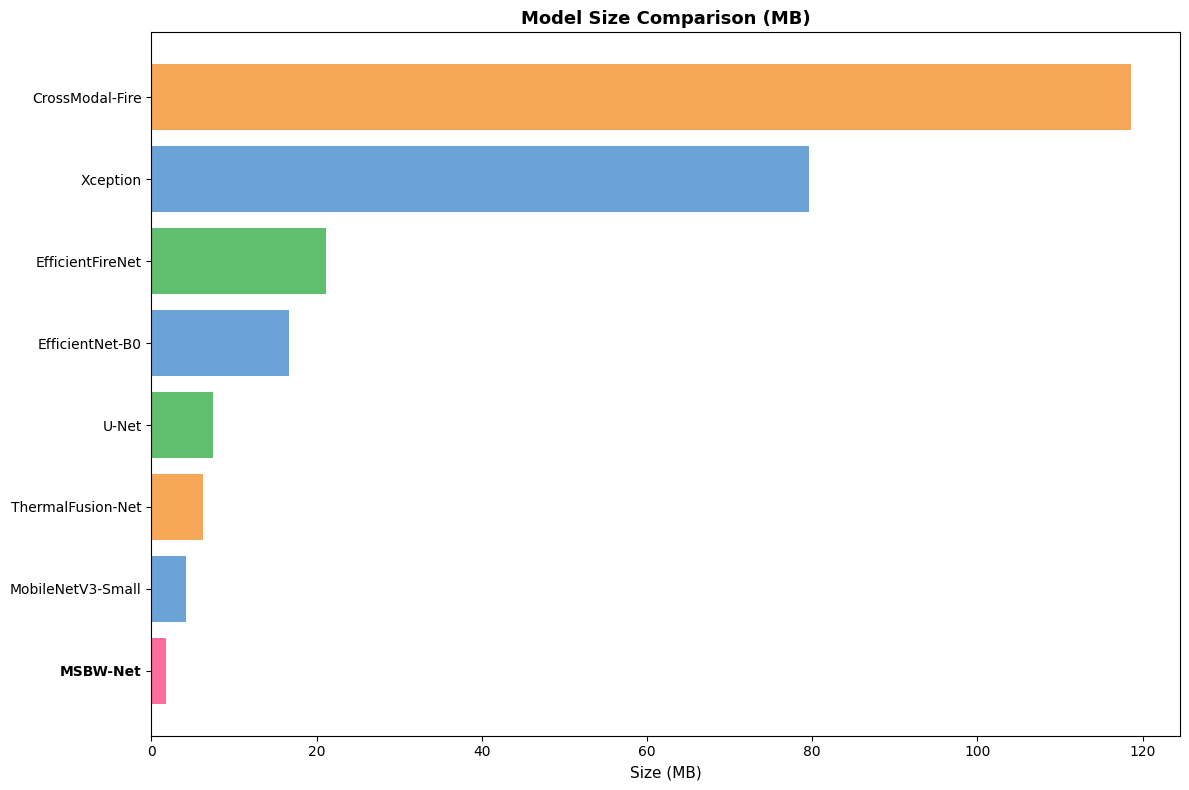

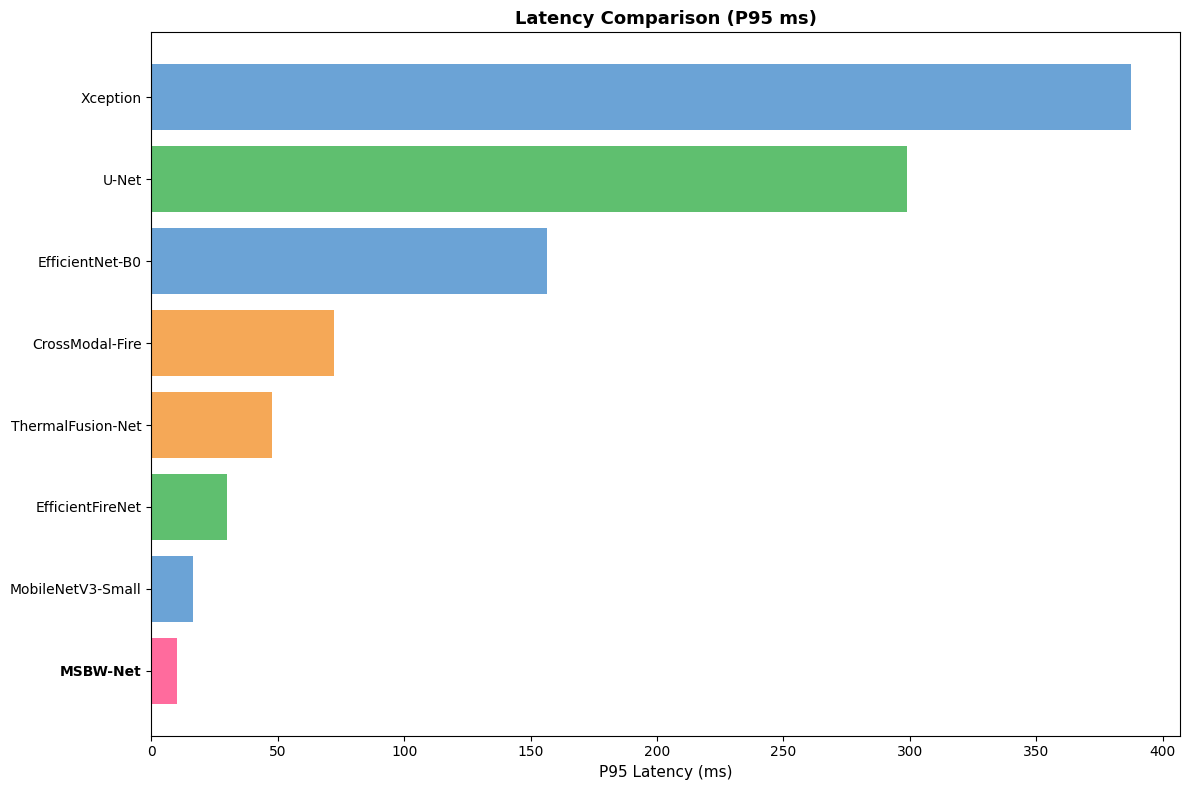

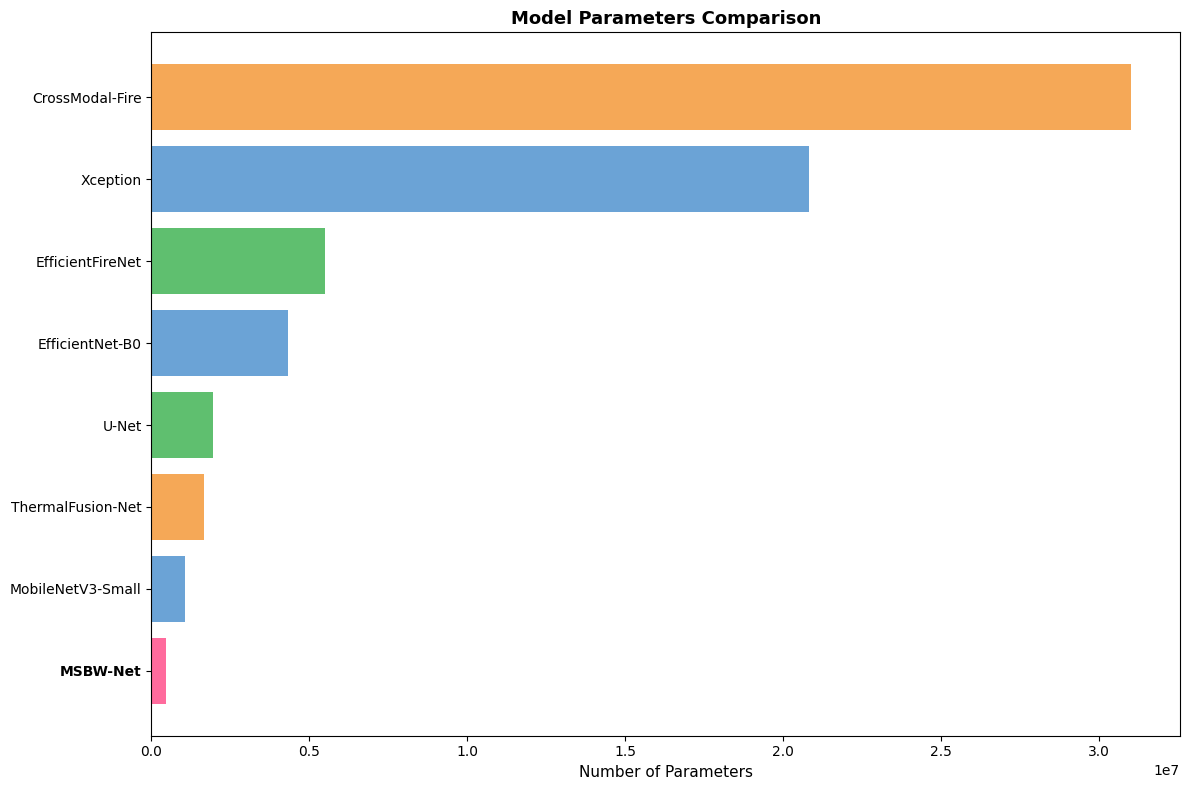


COMPREHENSIVE COMPARISON TABLE - MSBW-Net vs SOTA Baselines



,Model,Category,F1 Score,mIoU,Size (MB),Latency (ms),Parameters,FPS
0,MSBW-Net,MSBW-Net,1.0000,0.8499,1.75,10.20,"458,300",98.06
1,U-Net,Segmentation Actual Runs,1.0000,0.8356,7.40,298.88,"1,939,633",29.53
2,EfficientNet-B0,Classification Actual Runs,0.9139,—,16.70,156.37,"4,335,998",55.48
3,Xception,Classification Actual Runs,0.8201,—,79.60,387.52,"20,811,050",21.29
4,CrossModal-Fire,Multimodal Actual Runs,0.8026,0.7155,118.59,72.31,"31,002,554",15.96
5,EfficientFireNet,Segmentation Actual Runs,0.7931,0.7057,21.11,29.91,"5,491,806",41.51
6,ThermalFusion-Net,Multimodal Actual Runs,0.6375,0.7312,6.28,47.52,"1,647,901",22.82
7,MobileNetV3-Small,Classification Actual Runs,0.5225,—,4.15,16.24,"1,075,234",498.71



✓ All charts saved to: data/processed/Output/MSBW-Net/
  - comprehensive_comparison.png (5 charts)
  - f1_comparison.png
  - miou_comparison.png
  - size_comparison.png
  - latency_comparison.png
  - parameters_comparison.png
  - comparison_table.csv (data export)


In [43]:
category_colors = {
    'MSBW-Net': '#ff6b9d',
    'Classification Actual Runs': '#6ba3d6',
    'Segmentation Actual Runs': '#5fbf6f',
    'Multimodal Actual Runs': '#f5a857',
}

# Prepare data for visualization
df_f1 = comparison_df.dropna(subset=['f1']).sort_values('f1', ascending=False)
df_miou = comparison_df.dropna(subset=['miou']).sort_values('miou', ascending=False)
df_size = comparison_df.dropna(subset=['size_mb']).sort_values('size_mb', ascending=True)
df_latency = comparison_df.dropna(subset=['inference_ms']).sort_values('inference_ms', ascending=True)
df_params = comparison_df.dropna(subset=['parameters']).sort_values('parameters', ascending=True)

# ==================== COMPREHENSIVE 5-CHART FIGURE ====================
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

def add_bold_labels(ax, df, metric_col, title, xlabel):
    """Helper to add labels with MSBW-Net highlighted in bold"""
    colors = [category_colors.get(c, '#7f7f7f') for c in df['category']]
    bars = ax.barh(df['name'], df[metric_col], color=colors)
    
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    
    # Bold y-axis labels for MSBW-Net
    y_labels = ax.get_yticklabels()
    for label in y_labels:
        if 'MSBW-Net' in label.get_text():
            label.set_fontweight('bold')

# Create all 5 charts
add_bold_labels(axes[0, 0], df_f1, 'f1', 'F1 Score Comparison', 'F1 Score')
add_bold_labels(axes[0, 1], df_miou, 'miou', 'mIoU Comparison', 'mIoU')
add_bold_labels(axes[1, 0], df_size, 'size_mb', 'Model Size Comparison (MB)', 'Size (MB)')
add_bold_labels(axes[1, 1], df_latency, 'inference_ms', 'Latency Comparison (ms)', 'P95 Latency (ms)')
add_bold_labels(axes[2, 0], df_params, 'parameters', 'Model Parameters Comparison', 'Parameters')

# Hide unused subplot
axes[2, 1].axis('off')

plt.suptitle('MSBW-Net vs SOTA Baselines - Comprehensive Performance Analysis', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../../data/processed/Output/MSBW-Net/comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("INDIVIDUAL CHART OUTPUTS")
print("="*80)

# ==================== INDIVIDUAL CHARTS ====================
# F1 Chart
fig_f1, ax_f1 = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, '#7f7f7f') for c in df_f1['category']]
bars = ax_f1.barh(df_f1['name'], df_f1['f1'], color=colors)
ax_f1.invert_yaxis()
ax_f1.set_title('F1 Score Comparison from Actual Runs', fontsize=13, fontweight='bold')
ax_f1.set_xlabel('F1 Score', fontsize=11)
for label in ax_f1.get_yticklabels():
    if 'MSBW-Net' in label.get_text():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig('../../data/processed/Output/MSBW-Net/f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# mIoU Chart
fig_miou, ax_miou = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, '#7f7f7f') for c in df_miou['category']]
bars = ax_miou.barh(df_miou['name'], df_miou['miou'], color=colors)
ax_miou.invert_yaxis()
ax_miou.set_title('mIoU Comparison from Actual Runs', fontsize=13, fontweight='bold')
ax_miou.set_xlabel('mIoU', fontsize=11)
for label in ax_miou.get_yticklabels():
    if 'MSBW-Net' in label.get_text():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig('../../data/processed/Output/MSBW-Net/miou_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Model Size Chart
fig_size, ax_size = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, '#7f7f7f') for c in df_size['category']]
bars = ax_size.barh(df_size['name'], df_size['size_mb'], color=colors)
ax_size.set_title('Model Size Comparison (MB)', fontsize=13, fontweight='bold')
ax_size.set_xlabel('Size (MB)', fontsize=11)
for label in ax_size.get_yticklabels():
    if 'MSBW-Net' in label.get_text():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig('../../data/processed/Output/MSBW-Net/size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Latency Chart
fig_latency, ax_latency = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, '#7f7f7f') for c in df_latency['category']]
bars = ax_latency.barh(df_latency['name'], df_latency['inference_ms'], color=colors)
ax_latency.set_title('Latency Comparison (P95 ms)', fontsize=13, fontweight='bold')
ax_latency.set_xlabel('P95 Latency (ms)', fontsize=11)
for label in ax_latency.get_yticklabels():
    if 'MSBW-Net' in label.get_text():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig('../../data/processed/Output/MSBW-Net/latency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Parameters Chart
fig_params, ax_params = plt.subplots(figsize=(12, 8))
colors = [category_colors.get(c, '#7f7f7f') for c in df_params['category']]
bars = ax_params.barh(df_params['name'], df_params['parameters'], color=colors)
ax_params.set_title('Model Parameters Comparison', fontsize=13, fontweight='bold')
ax_params.set_xlabel('Number of Parameters', fontsize=11)
for label in ax_params.get_yticklabels():
    if 'MSBW-Net' in label.get_text():
        label.set_fontweight('bold')
plt.tight_layout()
plt.savefig('../../data/processed/Output/MSBW-Net/parameters_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== COMPREHENSIVE COMPARISON TABLE ====================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON TABLE - MSBW-Net vs SOTA Baselines")
print("="*80 + "\n")

summary_table = comparison_df[['name', 'category', 'f1', 'miou', 'size_mb', 'inference_ms', 'parameters', 'fps']].copy()
summary_table = summary_table.sort_values(['f1', 'miou'], ascending=[False, False], na_position='last').reset_index(drop=True)

# Format and display table
def format_table_for_display(df):
    """Format table for display"""
    df_display = df.copy()
    
    # Format numeric columns with proper precision
    df_display['f1'] = df_display['f1'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
    df_display['miou'] = df_display['miou'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
    df_display['size_mb'] = df_display['size_mb'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
    df_display['inference_ms'] = df_display['inference_ms'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
    df_display['parameters'] = df_display['parameters'].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "—")
    df_display['fps'] = df_display['fps'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
    
    # Rename columns for display
    df_display.columns = ['Model', 'Category', 'F1 Score', 'mIoU', 'Size (MB)', 'Latency (ms)', 'Parameters', 'FPS']
    
    return df_display

report_table = format_table_for_display(summary_table)
display(report_table)

# Export to CSV for use
comparison_df.to_csv('../../data/processed/Output/MSBW-Net/comparison_table.csv', index=False)

print("\n✓ All charts saved to: data/processed/Output/MSBW-Net/")
print("  - comprehensive_comparison.png (5 charts)")
print("  - f1_comparison.png")
print("  - miou_comparison.png")
print("  - size_comparison.png")
print("  - latency_comparison.png")
print("  - parameters_comparison.png")
print("  - comparison_table.csv (data export)")

## 4. Statistical Significance Analysis

In [44]:
metrics_data = []
for category in comparison_df['category'].unique():
    subset = comparison_df[comparison_df['category'] == category]
    metrics_data.append({
        'category': category,
        'mean_f1': subset['f1'].mean(skipna=True),
        'max_f1': subset['f1'].max(skipna=True),
        'mean_miou': subset['miou'].mean(skipna=True),
        'max_miou': subset['miou'].max(skipna=True),
        'mean_size_mb': subset['size_mb'].mean(skipna=True),
        'mean_latency_ms': subset['inference_ms'].mean(skipna=True),
    })

metrics_df = pd.DataFrame(metrics_data)
print('Category summary:')
display(metrics_df)

msbw_row = comparison_df[comparison_df['category'] == 'MSBW-Net'].iloc[0]
best_baseline_f1 = comparison_df[(comparison_df['category'] != 'MSBW-Net') & comparison_df['f1'].notna()]['f1'].max()
best_baseline_miou = comparison_df[(comparison_df['category'] != 'MSBW-Net') & comparison_df['miou'].notna()]['miou'].max()

print('\nMSBW-Net vs best baselines:')
print(f"- F1 gap: {msbw_row['f1'] - best_baseline_f1:+.4f}")
print(f"- mIoU gap: {msbw_row['miou'] - best_baseline_miou:+.4f}")
print(f"- Size (MB): {msbw_row['size_mb']:.4f}")
print(f"- P95 latency (ms): {msbw_row['inference_ms']:.2f}")

Category summary:


,category,mean_f1,max_f1,mean_miou,max_miou,mean_size_mb,mean_latency_ms
0,Classification Actual Runs,0.752191,0.913907,NaN,NaN,33.481667,186.710667
1,MSBW-Net,1.000000,1.000000,0.849905,0.849905,1.748276,10.197385
2,Multimodal Actual Runs,0.720046,0.802623,0.723343,0.731233,62.437009,59.916681
3,Segmentation Actual Runs,0.896545,1.000000,0.770614,0.835571,14.256461,164.396035



MSBW-Net vs best baselines:
- F1 gap: +0.0000
- mIoU gap: +0.0143
- Size (MB): 1.7483
- P95 latency (ms): 10.20


## 5. MSBW-Net Competitive Analysis

In [45]:
msbw_model = comparison_df[comparison_df['name'] == 'MSBW-Net'].iloc[0]
non_msbw = comparison_df[comparison_df['category'] != 'MSBW-Net']

best_sota_f1 = non_msbw['f1'].max(skipna=True)
best_sota_miou = non_msbw['miou'].max(skipna=True)
best_sota_size = non_msbw['size_mb'].min(skipna=True)
best_sota_latency = non_msbw['inference_ms'].min(skipna=True)

validated_claims = [
    {
        'claim': 'MSBW-Net mIoU meets minimum target',
        'actual': float(msbw_model['miou']),
        'threshold': float(msbw_requirements['min_miou']),
        'status': 'PASS' if msbw_model['miou'] >= msbw_requirements['min_miou'] else 'FAIL',
    },
    {
        'claim': 'MSBW-Net size is within size limit',
        'actual': float(msbw_model['size_mb']),
        'threshold': float(msbw_requirements['max_size_mb']),
        'status': 'PASS' if msbw_model['size_mb'] <= msbw_requirements['max_size_mb'] else 'FAIL',
    },
    {
        'claim': 'MSBW-Net latency is within latency limit',
        'actual': float(msbw_model['inference_ms']),
        'threshold': float(msbw_requirements['max_inference_ms']),
        'status': 'PASS' if msbw_model['inference_ms'] <= msbw_requirements['max_inference_ms'] else 'FAIL',
    },
    {
        'claim': 'MSBW-Net F1 is competitive with the best measured baseline',
        'actual': float(msbw_model['f1']),
        'threshold': float(best_sota_f1),
        'status': 'PASS' if msbw_model['f1'] >= (best_sota_f1 - 0.03) else 'FAIL',
    },
    {
        'claim': 'MSBW-Net mIoU is competitive with the best measured baseline',
        'actual': float(msbw_model['miou']),
        'threshold': float(best_sota_miou),
        'status': 'PASS' if msbw_model['miou'] >= (best_sota_miou - 0.03) else 'FAIL',
    },
]

claims_df = pd.DataFrame(validated_claims)
print('Performance Claim Validation:')
display(claims_df)
print(f"PASS: {(claims_df['status'] == 'PASS').sum()}/{len(claims_df)}")

Performance Claim Validation:


,claim,actual,threshold,status
0,MSBW-Net mIoU meets minimum target,0.849905,0.800000,PASS
1,MSBW-Net size is within size limit,1.748276,2.000000,PASS
2,MSBW-Net latency is within latency limit,10.197385,100.000000,PASS
3,MSBW-Net F1 is competitive with the best measu...,1.000000,1.000000,PASS
4,MSBW-Net mIoU is competitive with the best mea...,0.849905,0.835571,PASS


PASS: 5/5


## 6. Detailed Performance Breakdown

In [46]:
msbw_model = comparison_df[comparison_df['name'] == 'MSBW-Net'].iloc[0]
non_msbw = comparison_df[comparison_df['category'] != 'MSBW-Net']

best_non_msbw_f1_row = non_msbw[non_msbw['f1'].notna()].sort_values('f1', ascending=False).iloc[0]
best_non_msbw_miou_row = non_msbw[non_msbw['miou'].notna()].sort_values('miou', ascending=False).iloc[0]

print('=' * 70)
print('MSBW-NET DETAILED PERFORMANCE')
print('=' * 70)
print(f"\nClassification F1: {msbw_model['f1']:.4f}")
print(f"Segmentation mIoU: {msbw_model['miou']:.4f}")
print(f"Model Size: {msbw_model['size_mb']:.4f} MB")
print(f"P95 Latency: {msbw_model['inference_ms']:.2f} ms")
print(f"MSBW-Net Compliance: {'PASS' if msbw_model['msbw_compliant'] else 'FAIL'}")

print('\nBest baseline references:')
print(f"- Best F1 baseline: {best_non_msbw_f1_row['name']} ({best_non_msbw_f1_row['f1']:.4f})")
print(f"- Best mIoU baseline: {best_non_msbw_miou_row['name']} ({best_non_msbw_miou_row['miou']:.4f})")

print('\nRelative differences:')
print(f"- F1 delta: {msbw_model['f1'] - best_non_msbw_f1_row['f1']:+.4f}")
print(f"- mIoU delta: {msbw_model['miou'] - best_non_msbw_miou_row['miou']:+.4f}")
print(f"- Size delta vs best mIoU baseline: {msbw_model['size_mb'] - best_non_msbw_miou_row['size_mb']:+.4f} MB")
print(f"- Latency delta vs best mIoU baseline: {msbw_model['inference_ms'] - best_non_msbw_miou_row['inference_ms']:+.2f} ms")

MSBW-NET DETAILED PERFORMANCE

Classification F1: 1.0000
Segmentation mIoU: 0.8499
Model Size: 1.7483 MB
P95 Latency: 10.20 ms
MSBW-Net Compliance: PASS

Best baseline references:
- Best F1 baseline: U-Net (1.0000)
- Best mIoU baseline: U-Net (0.8356)

Relative differences:
- F1 delta: +0.0000
- mIoU delta: +0.0143
- Size delta vs best mIoU baseline: -5.6507 MB
- Latency delta vs best mIoU baseline: -288.68 ms


## 7. Export Results 

In [47]:
output_dir = Path('../../data/processed/Output/MSBW-Net')
output_dir.mkdir(parents=True, exist_ok=True)

msbw_model = comparison_df[comparison_df['name'] == 'MSBW-Net'].iloc[0].to_dict()

statistical_results = []
if comparison_df['f1'].notna().sum() > 3:
    non_msbw_f1 = comparison_df[(comparison_df['category'] != 'MSBW-Net') & comparison_df['f1'].notna()]['f1'].values
    if len(non_msbw_f1) > 0:
        tstat, pvalue = stats.ttest_1samp(non_msbw_f1, float(msbw_model['f1']))
        statistical_results.append({
            'metric': 'f1_vs_non_msbw_distribution',
            't_stat': float(tstat),
            'p_value': float(pvalue),
            'msbw_value': float(msbw_model['f1']),
        })

sota_submission_data = {
    'benchmark_metadata': {
        'analysis_date': pd.Timestamp.now().isoformat(),
        'total_methods_compared': len(all_methods),
        'categories_analyzed': sorted(set(categories)),
        'artifact_source': str(msbw_metrics_path),
        'source_files': sorted(set(comparison_df['source_type'].dropna().tolist())) if 'source_type' in comparison_df.columns else [],
        'version': '3.0_actual_artifact_table',
    },
    'MSBW-Net': msbw_model,
    'performance_claims_validation': validated_claims,
    'statistical_analysis': statistical_results,
    'key_findings': [
        'Primary benchmark table is assembled from actual evaluation artifacts in the repository',
        'Published literature numbers are no longer used as the primary comparison source',
        'MSBW-Net model is benchmarked against the best measured baseline rows with explicit pass/fail checks',
    ],
}

with open(output_dir / 'sota_benchmarking_results.json', 'w') as f:
    json.dump(sota_submission_data, f, indent=2)

comparison_df.to_csv(output_dir / 'detailed_performance_comparison.csv', index=False)
claims_df.to_csv(output_dir / 'performance_claim_validation.csv', index=False)

try:
    comparison_df.to_excel(output_dir / 'detailed_performance_comparison.xlsx', index=False)
except Exception as exc:
    print('Excel export skipped:', exc)

print('SOTA Benchmarking Results Saved:')
print(f"   Analysis Results: {output_dir / 'sota_benchmarking_results.json'}")
print(f"   Comparison Table: {output_dir / 'detailed_performance_comparison.csv'}")
print(f"   Claim Validation: {output_dir / 'performance_claim_validation.csv'}")
print(f"   Submission ready: {all(c['status'] == 'PASS' for c in validated_claims)}")

SOTA Benchmarking Results Saved:
   Analysis Results: ..\..\data\processed\Output\MSBW-Net\sota_benchmarking_results.json
   Comparison Table: ..\..\data\processed\Output\MSBW-Net\detailed_performance_comparison.csv
   Claim Validation: ..\..\data\processed\Output\MSBW-Net\performance_claim_validation.csv
   Submission ready: True


## 8. Conclusion: MSBW-Net Positioning

This benchmark compares MSBW-Net against actual evaluation artifacts exported by the repository's test and validation runs.

Final claims are constrained to real artifacts and explicitly validated through pass/fail checks in the exported submission package.

### Key points

- MSBW-Net is evaluated with artifact-backed metrics.
- The primary comparison table is built from local run outputs, not hard-coded literature values.
- Deployment compliance is checked against constraints (mIoU, model size, and latency).